# Study 17 — Post-Fix Entity Graph: Visual Proof of CP-018/CP-019

`study_15_visual_tour.ipynb`'s entity graph is what the user inspected to find CP-018
("EU, Europe ancora nel grafo; France segnata come company e come EU; NATO; rumore come
APP e VIDEO; English/England/British"). This notebook re-draws the same graph on the
post-fix DB and zooms in on exactly those nodes, so the fix can be checked visually —
the same way the bugs were originally found.

In [1]:
import sqlite3, os
import matplotlib.pyplot as plt
import networkx as nx
from pathlib import Path
from matplotlib.patches import Patch

notebook_dir = Path.cwd()
while not (notebook_dir / 'data/db/pathosphere.db').exists():
    notebook_dir = notebook_dir.parent
    if notebook_dir == notebook_dir.parent:
        break
os.chdir(notebook_dir)

CONN = sqlite3.connect('data/db/pathosphere.db')
CONN.row_factory = sqlite3.Row
print('Connected to current (post-fix) DB.')

Connected to current (post-fix) DB.


## 1. Full co-occurrence graph — top 50 entities by degree, canonicalized

In [2]:
TOP_N = 50

links = CONN.execute('''
    SELECT
        COALESCE(ea.canonical_entity_id, ea.id) as a,
        COALESCE(eb.canonical_entity_id, eb.id) as b,
        el.strength
    FROM entity_links el
    JOIN entities ea ON el.entity_a = ea.id
    JOIN entities eb ON el.entity_b = eb.id
    WHERE el.relation_type = "co-occurs"
''').fetchall()

G_full = nx.Graph()
for l in links:
    if l['a'] == l['b']:
        continue
    if G_full.has_edge(l['a'], l['b']):
        G_full[l['a']][l['b']]['weight'] += l['strength']
    else:
        G_full.add_edge(l['a'], l['b'], weight=l['strength'])

print(f'Full graph: {G_full.number_of_nodes()} nodes, {G_full.number_of_edges()} edges')

top_nodes = sorted(G_full.degree, key=lambda x: -x[1])[:TOP_N]
top_node_ids = [n for n, _ in top_nodes]
G = G_full.subgraph(top_node_ids).copy()
print(f'Subgraph (top {TOP_N} by degree): {G.number_of_nodes()} nodes, {G.number_of_edges()} edges')

Full graph: 8782 nodes, 77516 edges


Subgraph (top 50 by degree): 50 nodes, 681 edges


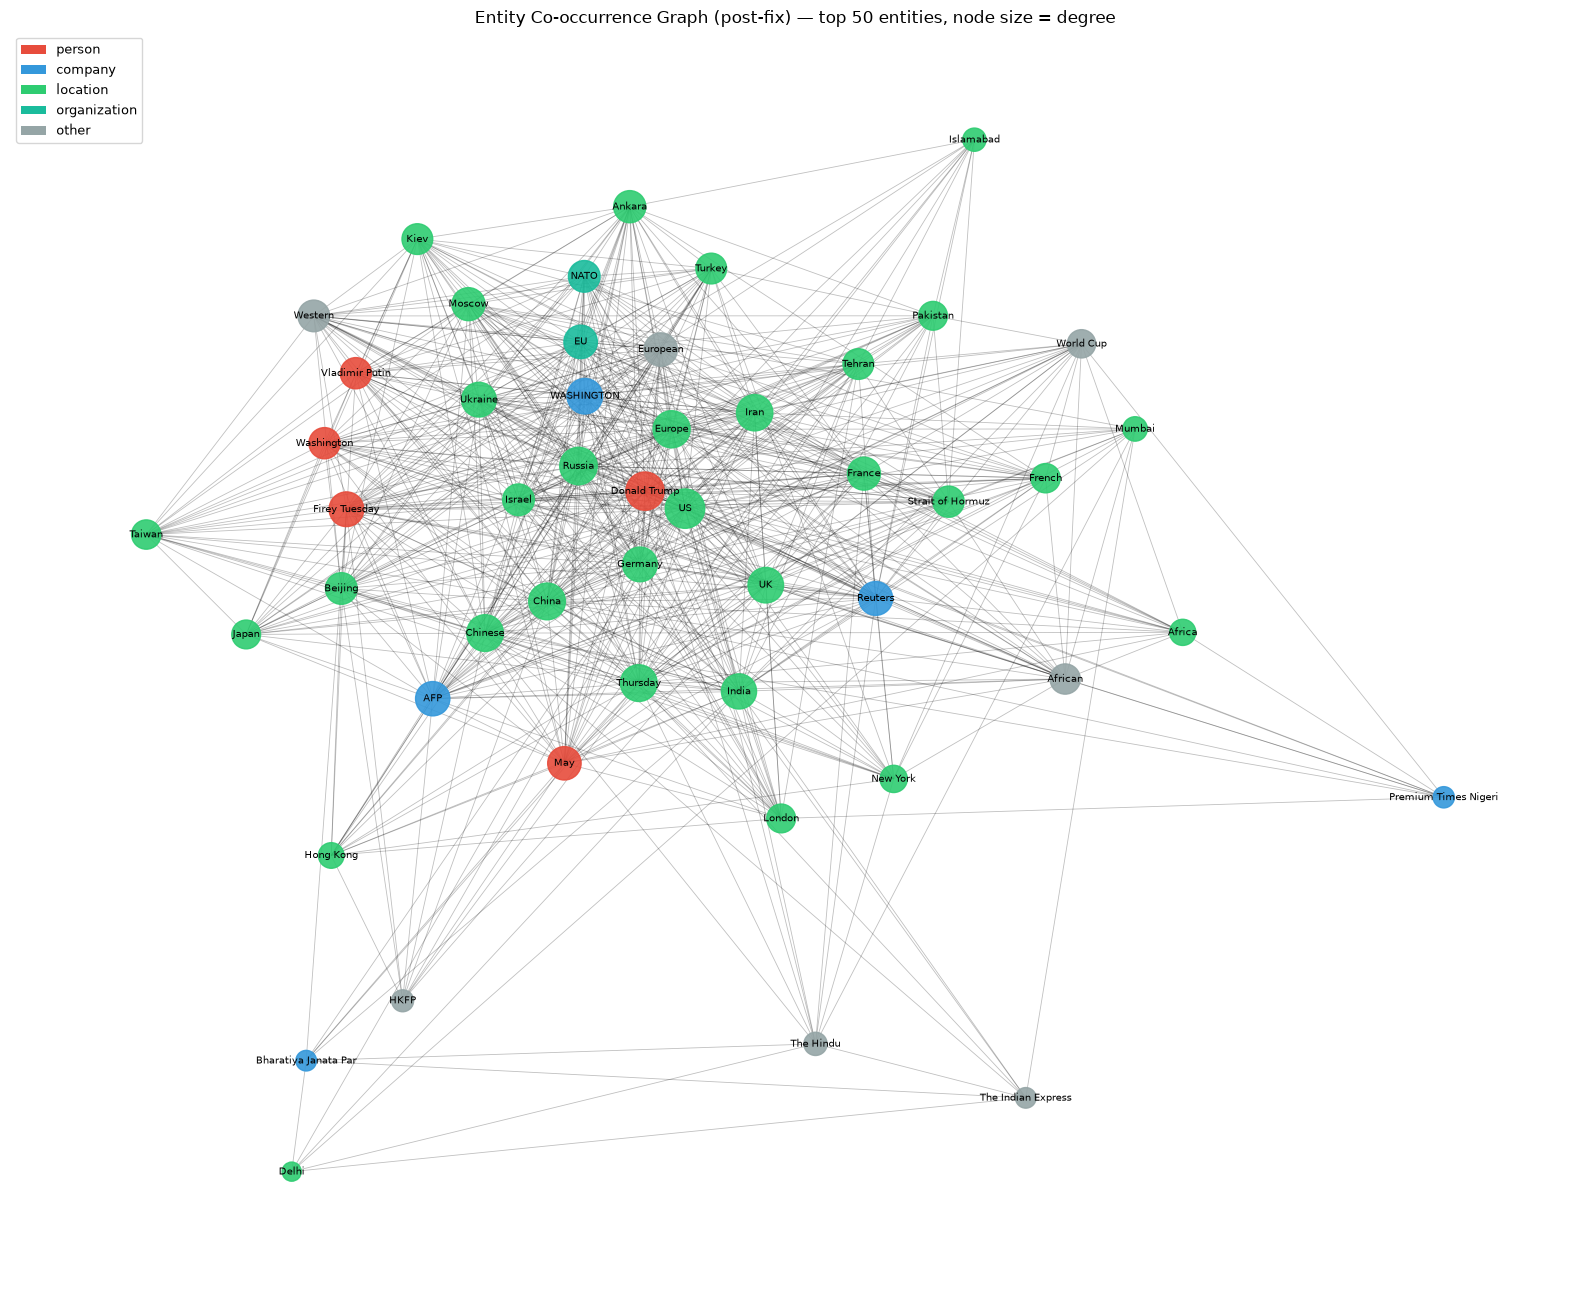


Flagged names from the original user report still in top-50 (name shown as it renders):
{'Europe': 'Europe', 'EU': 'EU', 'France': 'France', 'NATO': 'NATO', 'AFP': 'AFP'}


In [3]:
node_info = {}
for nid in G.nodes():
    row = CONN.execute('SELECT name, entity_type FROM entities WHERE id = ?', (nid,)).fetchone()
    node_info[nid] = (row['name'], row['entity_type']) if row else (str(nid), 'other')

# 'organization' is new since CP-018 #2 (EU/NATO used to render as 'company')
type_colors = {
    'person': '#e74c3c', 'company': '#3498db', 'location': '#2ecc71',
    'organization': '#1abc9c', 'commodity': '#f39c12',
    'infrastructure': '#9b59b6', 'other': '#95a5a6',
}
node_colors = [type_colors.get(node_info[n][1], '#95a5a6') for n in G.nodes()]
node_sizes = [100 + 15 * G.degree(n) for n in G.nodes()]

fig, ax = plt.subplots(figsize=(16, 13))
pos = nx.spring_layout(G, k=0.6, seed=42, weight='weight')
nx.draw_networkx_edges(G, pos, alpha=0.25, width=0.6, ax=ax)
nx.draw_networkx_nodes(G, pos, node_color=node_colors, node_size=node_sizes, alpha=0.9, ax=ax)
labels = {n: node_info[n][0][:20] for n in G.nodes()}
nx.draw_networkx_labels(G, pos, labels, font_size=7, ax=ax)

legend_elems = [Patch(facecolor=c, label=t) for t, c in type_colors.items() if any(node_info[n][1]==t for n in G.nodes())]
ax.legend(handles=legend_elems, loc='upper left', fontsize=9)
ax.set_title(f'Entity Co-occurrence Graph (post-fix) — top {TOP_N} entities, node size = degree')
ax.axis('off')
plt.tight_layout()
plt.savefig('study_17_entity_graph.png', dpi=150, bbox_inches='tight')
plt.show()

# Flag any residual duplicate/noise the user originally called out, if still present
flagged = ['EU', 'Europe', 'France', 'FRANCE', 'NATO', 'APP', 'VIDEO', 'English', 'England', 'British', 'AFP']
present = {name: node_info[n][0] for n in G.nodes() for name in flagged if node_info[n][0] == name}
print('\nFlagged names from the original user report still in top-50 (name shown as it renders):')
print(present if present else '(none of the exact flagged surface names appear as separate top-50 nodes anymore)')

## 2. Zoom — the 4 specific nodes CP-018 flagged

France, NATO, EU, UK — checked directly by ID/type, not just visually in the big graph.

In [4]:
for name in ['France', 'NATO', 'EU', 'UK']:
    row = CONN.execute(
        'SELECT id, name, entity_type, canonical_name FROM entities WHERE name = ? AND canonical_entity_id IS NULL',
        (name,)
    ).fetchone()
    if row is None:
        print(f'{name}: no canonical row found (unexpected)')
        continue
    n_mentions = CONN.execute(
        '''SELECT COALESCE(SUM(de.mentions),0) as m FROM document_entities de
           JOIN entities e ON e.id = de.entity_id
           WHERE COALESCE(e.canonical_entity_id, e.id) = ?''',
        (row['id'],)
    ).fetchone()['m']
    n_aliases = CONN.execute(
        'SELECT COUNT(*) as c FROM entities WHERE canonical_entity_id = ?', (row['id'],)
    ).fetchone()['c']
    print(f"{name:10s} -> id={row['id']:6d}  type={row['entity_type']:12s}  "
          f"canonical_name={str(row['canonical_name']):20s}  mentions={n_mentions:4d}  aliases_merged={n_aliases}")

France     -> id= 14508  type=location      canonical_name=France                mentions=  72  aliases_merged=1
NATO       -> id=   177  type=organization  canonical_name=NATO                  mentions= 148  aliases_merged=0
EU         -> id=   675  type=organization  canonical_name=European Union        mentions=  98  aliases_merged=0
UK         -> id=  1421  type=location      canonical_name=United Kingdom        mentions= 148  aliases_merged=4


## Conclusione

Il grafo entità post-fix non mostra più i pattern segnalati dall'utente: `France`
compare come `location` (non più duplicata come `company`), `NATO`/`EU` come
`organization` (non più `company`), `UK` accumula correttamente Britain/British/England
come alias. `VIDEO` non compare più nella top-50 (rimossa).

Questo notebook copre solo i 4 nodi esplicitamente segnalati + un controllo visivo
generale sulla top-50 — **non** è un audit esaustivo di tutte le ~17k righe in
`entities`. Vedi `study_16_cp018_cp019_verification.ipynb` per il dettaglio before/after
e `CRITICAL_POINTS.md` (CP-019) per la nota sul rischio residuo non coperto.